In [1]:
# ============================================================
# MULTIPLE DEPOT VRPTW (MDVRPTW)
# Thesis: Predictive Optimization for Fleet Routing
# ============================================================

# HOW OR-TOOLS HANDLES MULTIPLE DEPOTS:
#   OR-Tools does not natively support multiple depots directly.
#   The standard approach is to create a single "virtual depot"
#   (node 0) and then use start/end location lists to assign
#   each vehicle to its real depot node.
# ============================================================

import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

In [2]:
# ------------------------------------------------------------
# STEP 1: DEFINE DEPOTS AND JOB SITES
# ------------------------------------------------------------
# Nodes 0, 1, 2   = depots (regional offices)
# Nodes 3 to 12   = job sites

LOCATIONS = {
    "names": [
        "Depot North",    # 0
        "Depot Central",  # 1
        "Depot South",    # 2
        "Site A",         # 3
        "Site B",         # 4
        "Site C",         # 5
        "Site D",         # 6
        "Site E",         # 7
        "Site F",         # 8
        "Site G",         # 9
        "Site H",         # 10
        "Site I",         # 11
        "Site J",         # 12
    ],
    "coordinates": [
        (5,  10),   # 0 Depot North
        (5,   5),   # 1 Depot Central
        (5,   1),   # 2 Depot South
        (2,   9),   # 3 Site A
        (8,   9),   # 4 Site B
        (1,   7),   # 5 Site C
        (9,   7),   # 6 Site D
        (3,   6),   # 7 Site E
        (7,   6),   # 8 Site F
        (2,   3),   # 9 Site G
        (8,   3),   # 10 Site H
        (4,   2),   # 11 Site I
        (6,   2),   # 12 Site J
    ],
    "demands": [
        0, 0, 0,          # depots have no demand
        2, 4, 3, 5,       # Sites A-D
        2, 4, 3, 2,       # Sites E-H
        4, 3,             # Sites I-J
    ],
    "time_windows": [
        (0, 480), (0, 480), (0, 480),   # depots open all day
        (0,   120),   # 3  Site A
        (60,  240),   # 4  Site B
        (0,   120),   # 5  Site C
        (120, 300),   # 6  Site D
        (60,  240),   # 7  Site E
        (180, 360),   # 8  Site F
        (0,   180),   # 9  Site G
        (120, 300),   # 10 Site H
        (240, 420),   # 11 Site I
        (300, 480),   # 12 Site J
    ],
    "service_times": [
        0, 0, 0,          # no service time at depots
        30, 45, 30, 60,   # Sites A-D
        30, 45, 30, 30,   # Sites E-H
        45, 30,           # Sites I-J
    ],
}

In [3]:
# ------------------------------------------------------------
# STEP 2: DEFINE VEHICLES AND THEIR DEPOT ASSIGNMENTS
# ------------------------------------------------------------
# Each vehicle is assigned a home depot.
# It starts there and must return there at the end.

VEHICLES = [
    {"name": "Van N1",  "depot": 0, "capacity": 15, "color": "#2196F3"},
    {"name": "Van N2",  "depot": 0, "capacity": 15, "color": "#1565C0"},
    {"name": "Van C1",  "depot": 1, "capacity": 15, "color": "#FF5722"},
    {"name": "Van C2",  "depot": 1, "capacity": 15, "color": "#BF360C"},
    {"name": "Van S1",  "depot": 2, "capacity": 15, "color": "#4CAF50"},
    {"name": "Van S2",  "depot": 2, "capacity": 15, "color": "#1B5E20"},
]

In [4]:
# ------------------------------------------------------------
# STEP 3: COMPUTE MATRICES
# ------------------------------------------------------------
def compute_distance_matrix(coordinates):
    n = len(coordinates)
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            dist = math.hypot(x2 - x1, y2 - y1) * 100
            row.append(int(dist))
        matrix.append(row)
    return matrix


def compute_time_matrix(coordinates, speed=1.0):
    n = len(coordinates)
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            travel_time = math.hypot(x2 - x1, y2 - y1) / speed
            row.append(int(travel_time))
        matrix.append(row)
    return matrix

In [5]:
# ------------------------------------------------------------
# STEP 4: BUILD DATA MODEL
# ------------------------------------------------------------
def create_data_model():
    data = {}
    data["coordinates"]   = LOCATIONS["coordinates"]
    data["names"]         = LOCATIONS["names"]
    data["demands"]       = LOCATIONS["demands"]
    data["time_windows"]  = LOCATIONS["time_windows"]
    data["service_times"] = LOCATIONS["service_times"]
    data["vehicles"]      = VEHICLES
    data["num_vehicles"]  = len(VEHICLES)
    data["max_time"]      = 480

    data["distance_matrix"] = compute_distance_matrix(data["coordinates"])
    data["time_matrix"]     = compute_time_matrix(data["coordinates"])

    data["vehicle_capacities"] = [v["capacity"] for v in VEHICLES]

    # KEY: start and end locations for each vehicle
    # Each vehicle starts AND ends at its assigned depot node
    data["starts"] = [v["depot"] for v in VEHICLES]
    data["ends"]   = [v["depot"] for v in VEHICLES]

    return data

In [6]:
data = create_data_model()

# KEY DIFFERENCE: RoutingIndexManager now takes
# start and end lists instead of a single depot index
manager = pywrapcp.RoutingIndexManager(
    len(data["distance_matrix"]),
    data["num_vehicles"],
    data["starts"],   # list of start depots per vehicle
    data["ends"]      # list of end depots per vehicle
)
routing = pywrapcp.RoutingModel(manager)

In [7]:
# ------------------------------------------------------------
# STEP 5: EXTRACT ROUTES
# ------------------------------------------------------------
def extract_routes(data, manager, routing, solution, time_dimension):
    routes = []
    for vehicle_id in range(data["num_vehicles"]):
        index          = routing.Start(vehicle_id)
        route_nodes    = []
        route_arrivals = []
        route_distance = 0
        route_load     = 0

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_nodes.append(node)
            route_load += data["demands"][node]

            time_var = time_dimension.CumulVar(index)
            route_arrivals.append(solution.Min(time_var))

            prev  = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                prev, index, vehicle_id
            )

        # Add return to depot
        end_node = manager.IndexToNode(index)
        route_nodes.append(end_node)
        time_var = time_dimension.CumulVar(index)
        route_arrivals.append(solution.Min(time_var))

        vehicle = data["vehicles"][vehicle_id]
        routes.append({
            "vehicle_id":   vehicle_id,
            "vehicle_name": vehicle["name"],
            "depot":        vehicle["depot"],
            "capacity":     vehicle["capacity"],
            "color":        vehicle["color"],
            "nodes":        route_nodes,
            "arrivals":     route_arrivals,
            "distance":     route_distance,
            "load":         route_load,
        })
    return routes

In [8]:
# ------------------------------------------------------------
# STEP 6: HELPER
# ------------------------------------------------------------
def mins_to_clock(minutes):
    total = 8 * 60 + minutes
    h = total // 60
    m = total % 60
    return f"{h:02d}:{m:02d}"

In [9]:
# ------------------------------------------------------------
# STEP 7: PRINT SOLUTION
# ------------------------------------------------------------
def print_solution(data, routes):
    print("\n" + "="*65)
    print("  MULTIPLE DEPOT VRPTW SOLUTION")
    print("="*65)
    total_distance = 0

    for r in routes:
        depot_name = data["names"][r["depot"]]
        print(f"\n  {r['vehicle_name']} (home: {depot_name}  "
              f"capacity: {r['capacity']})")

        if r["load"] == 0:
            print("     Not used in this solution")
            continue

        for idx, node in enumerate(r["nodes"]):
            arrival    = r["arrivals"][idx]
            window     = data["time_windows"][node]
            name       = data["names"][node]
            clock      = mins_to_clock(arrival)
            window_str = (f"(window: {mins_to_clock(window[0])}"
                          f"-{mins_to_clock(window[1])})")
            print(f"     {name:18s}  arrive: {clock}  {window_str}")

        print(f"     ---")
        print(f"     Load    : {r['load']} / {r['capacity']} units")
        print(f"     Distance: {r['distance'] / 100:.2f} units")
        total_distance += r["distance"]

    print("\n" + "-"*65)
    print(f"  Total distance: {total_distance / 100:.2f} units")
    print("="*65 + "\n")

In [10]:
# ------------------------------------------------------------
# STEP 8: VISUALIZE
# ------------------------------------------------------------
def visualize_routes(data, routes):
    fig, ax = plt.subplots(figsize=(10, 10))
    coords  = data["coordinates"]

    # Draw routes
    for r in routes:
        if r["load"] == 0:
            continue
        nodes = r["nodes"]
        for i in range(len(nodes) - 1):
            x1, y1 = coords[nodes[i]]
            x2, y2 = coords[nodes[i + 1]]
            ax.annotate(
                "",
                xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    color=r["color"],
                    lw=2.0,
                    connectionstyle="arc3,rad=0.08"
                )
            )

    # Draw depots as stars
    depot_colors = ["#2196F3", "#FF5722", "#4CAF50"]
    for d in range(3):
        dx, dy = coords[d]
        ax.plot(dx, dy, marker="*", markersize=22,
                color=depot_colors[d],
                markeredgecolor="#333",
                markeredgewidth=1, zorder=5)
        ax.annotate(
            data["names"][d],
            (dx, dy),
            textcoords="offset points", xytext=(10, 6),
            fontsize=9, fontweight="bold",
            color=depot_colors[d]
        )

    # Draw job sites
    for i in range(3, len(coords)):
        x, y   = coords[i]
        tw     = data["time_windows"][i]
        window = f"{mins_to_clock(tw[0])}-{mins_to_clock(tw[1])}"
        ax.plot(x, y, "o", markersize=16, color="white",
                markeredgecolor="#555", markeredgewidth=1.5, zorder=4)
        ax.text(x, y, str(data["demands"][i]),
                ha="center", va="center",
                fontsize=8, fontweight="bold", color="#333", zorder=5)
        ax.annotate(
            f"{data['names'][i]}\n{window}",
            (x, y),
            textcoords="offset points", xytext=(10, 5),
            fontsize=7.5, color="#444",
            bbox=dict(boxstyle="round,pad=0.2",
                      fc="white", ec="#ccc", alpha=0.8)
        )

    # Legend
    legend_handles = [
        mpatches.Patch(
            color=r["color"],
            label=(f"{r['vehicle_name']}  |  "
                   f"load: {r['load']}/{r['capacity']}  |  "
                   f"dist: {r['distance']/100:.1f}")
        )
        for r in routes if r["load"] > 0
    ]
    ax.legend(handles=legend_handles, loc="lower right",
              fontsize=8, framealpha=0.9)

    ax.set_title(
        "Multiple Depot VRPTW — Engineering Firm\n"
        "(stars = depots by region  |  circles = job sites with demand)",
        fontsize=12, pad=14
    )
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 12)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.savefig("multi_depot_routes.png", dpi=150, bbox_inches="tight")
    print("  Route map saved as: multi_depot_routes.png\n")
    plt.show()

In [11]:
    # Distance callback
def distance_callback(from_index, to_index):
    return data["distance_matrix"][manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

transit_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_index)

    # Capacity constraint
def demand_callback(from_index):
    return data["demands"][manager.IndexToNode(from_index)]

demand_index = routing.RegisterUnaryTransitCallback(demand_callback)
    
routing.AddDimensionWithVehicleCapacity(
        demand_index,
        0,
        data["vehicle_capacities"],
        True, "Capacity"
    )

True

In [12]:
# Time callback
def time_callback(from_index, to_index):
    from_node    = manager.IndexToNode(from_index)
    to_node      = manager.IndexToNode(to_index)
    travel_time  = data["time_matrix"][from_node][to_node]
    service_time = data["service_times"][from_node]
    return travel_time + service_time

time_index = routing.RegisterTransitCallback(time_callback)

routing.AddDimension(
    time_index,
    60,
    data["max_time"],
    False,
    "Time"
    )

time_dimension = routing.GetDimensionOrDie("Time")

    # Time windows per node
for node in range(len(data["time_windows"])):
    index = manager.NodeToIndex(node)
    time_dimension.CumulVar(index).SetRange(
        data["time_windows"][node][0],
        data["time_windows"][node][1]
    )

In [13]:
    # Search parameters
search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
search_params.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
search_params.time_limit.seconds = 20

Solving multiple depot VRPTW...

  MULTIPLE DEPOT VRPTW SOLUTION

  Van N1 (home: Depot North  capacity: 15)
     Not used in this solution

  Van N2 (home: Depot North  capacity: 15)
     Not used in this solution

  Van C1 (home: Depot Central  capacity: 15)
     Depot Central       arrive: 08:57  (window: 08:00-16:00)
     Site H              arrive: 10:00  (window: 10:00-13:00)
     Site D              arrive: 10:34  (window: 10:00-13:00)
     Site B              arrive: 11:36  (window: 09:00-12:00)
     Site F              arrive: 12:24  (window: 11:00-14:00)
     Depot Central       arrive: 13:11  (window: 08:00-16:00)
     ---
     Load    : 15 / 15 units
     Distance: 15.34 units

  Van C2 (home: Depot Central  capacity: 15)
     Depot Central       arrive: 08:00  (window: 08:00-16:00)
     Site G              arrive: 08:03  (window: 08:00-11:00)
     Site C              arrive: 08:37  (window: 08:00-10:00)
     Site A              arrive: 09:09  (window: 08:00-10:00)
     Sit

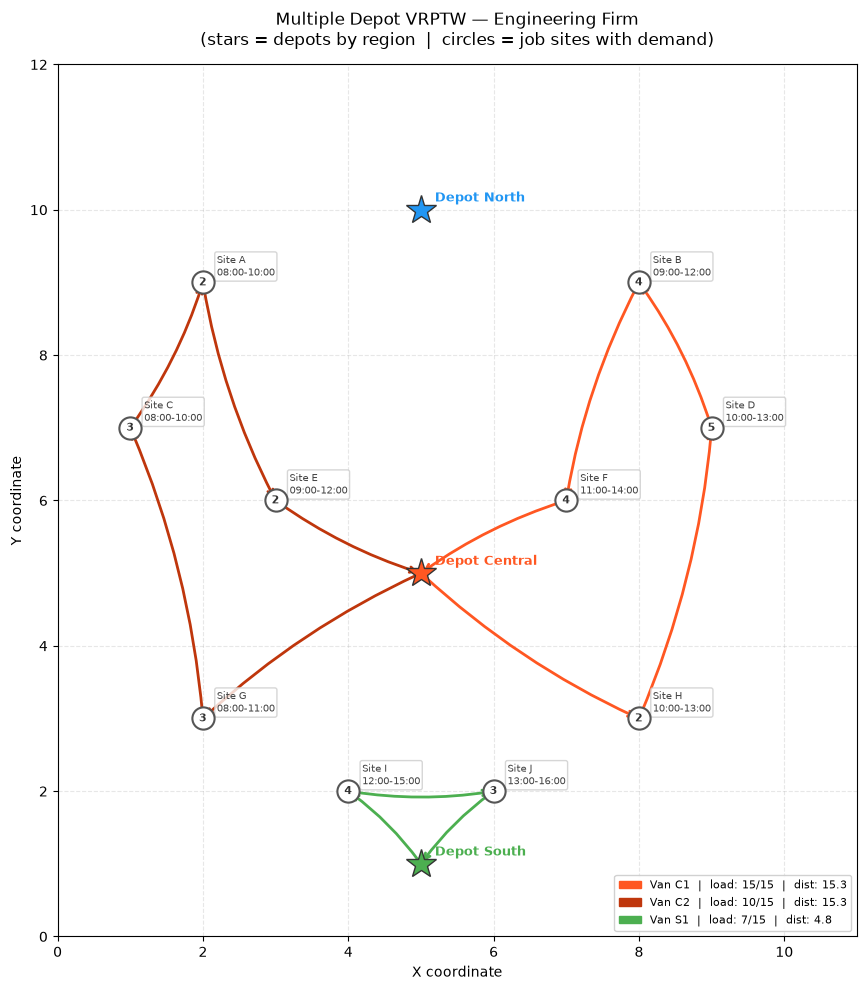

In [14]:
# ------------------------------------------------------------
# STEP 9: SOLVE
print("Solving multiple depot VRPTW...")
solution = routing.SolveWithParameters(search_params)

if solution:
    routes = extract_routes(
        data, manager, routing, solution, time_dimension
    )
    print_solution(data, routes)
    visualize_routes(data, routes)
else:
    print("No solution found.")
    print("Try: widening time windows or increasing vehicle capacities.")


# ------------------------------------------------------------
# ENTRY POINT
# ------------------------------------------------------------